# Comparing Data Visualizations
## Life Expectancy Comparison: Asia vs Africa (1952)

This notebook loads the countries.csv dataset and compares life expectancy
distributions between Asia and Africa for the year 1952 using histograms.

In [1]:
# Import required libraries
# pandas is used for data loading and manipulation
# matplotlib.pyplot provides the plotting functions (hist, subplot)
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the countries CSV file into a pandas DataFrame
# This dataset contains country-level data including life expectancy,
# population, and GDP per capita across multiple years and continents
df = pd.read_csv('countries.csv')

# Display the first few rows to understand the data structure
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (167, 6)
Columns: ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap']


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [3]:
# Filter the dataset to only include records from the year 1952
# We are comparing life expectancy between Asia and Africa for this year
df_1952 = df[df['year'] == 1952]

# Create separate DataFrames for Asia and Africa
# These will be used as the two time series for our comparison
asia_1952 = df_1952[df_1952['continent'] == 'Asia']['lifeExp']
africa_1952 = df_1952[df_1952['continent'] == 'Africa']['lifeExp']

# Display summary statistics for each continent's life expectancy
print('=== Asia Life Expectancy (1952) ===')
print(asia_1952.describe())
print(f'\nNumber of countries: {len(asia_1952)}')

print('\n=== Africa Life Expectancy (1952) ===')
print(africa_1952.describe())
print(f'\nNumber of countries: {len(africa_1952)}')

=== Asia Life Expectancy (1952) ===
count    30.000000
mean     45.806633
std       9.315530
min      28.801000
25%      38.037750
50%      44.434500
75%      50.916250
max      65.390000
Name: lifeExp, dtype: float64

Number of countries: 30

=== Africa Life Expectancy (1952) ===
count    52.000000
mean     39.135500
std       5.151581
min      30.000000
25%      35.811750
50%      38.833000
75%      42.117750
max      52.724000
Name: lifeExp, dtype: float64

Number of countries: 52


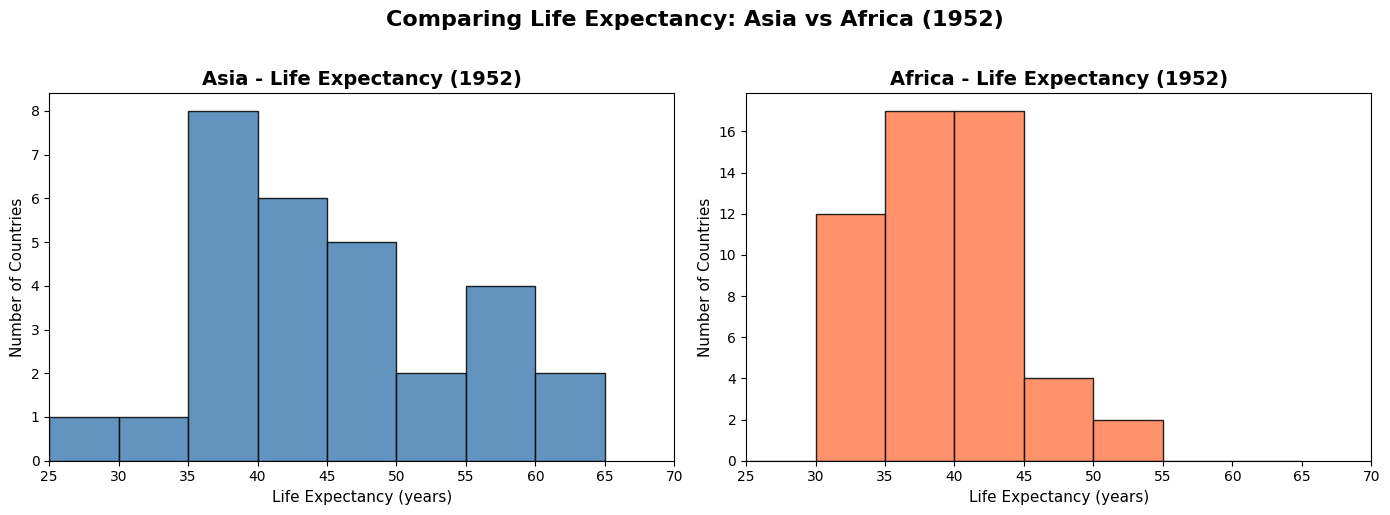

In [4]:
# Create side-by-side histograms using subplot() to compare
# life expectancy distributions between Asia and Africa in 1952

# Set up the figure with 1 row and 2 columns of subplots
# figsize controls the overall width and height of the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Define shared bin edges so both histograms use the same x-axis scale
# This makes visual comparison between the two distributions easier
bins = range(25, 70, 5)

# Plot the histogram for Asia's life expectancy on the left subplot
# color is set to a distinct color for easy differentiation
# edgecolor adds borders to each bar for clarity
ax1.hist(asia_1952, bins=bins, color='steelblue', edgecolor='black', alpha=0.85)
ax1.set_title('Asia - Life Expectancy (1952)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Life Expectancy (years)', fontsize=11)
ax1.set_ylabel('Number of Countries', fontsize=11)
ax1.set_xlim(25, 70)  # Set consistent x-axis limits for comparison

# Plot the histogram for Africa's life expectancy on the right subplot
ax2.hist(africa_1952, bins=bins, color='coral', edgecolor='black', alpha=0.85)
ax2.set_title('Africa - Life Expectancy (1952)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Life Expectancy (years)', fontsize=11)
ax2.set_ylabel('Number of Countries', fontsize=11)
ax2.set_xlim(25, 70)  # Match the x-axis limits with the Asia plot

# Add a main title for the entire figure
fig.suptitle('Comparing Life Expectancy: Asia vs Africa (1952)',
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Display the plots
plt.show()

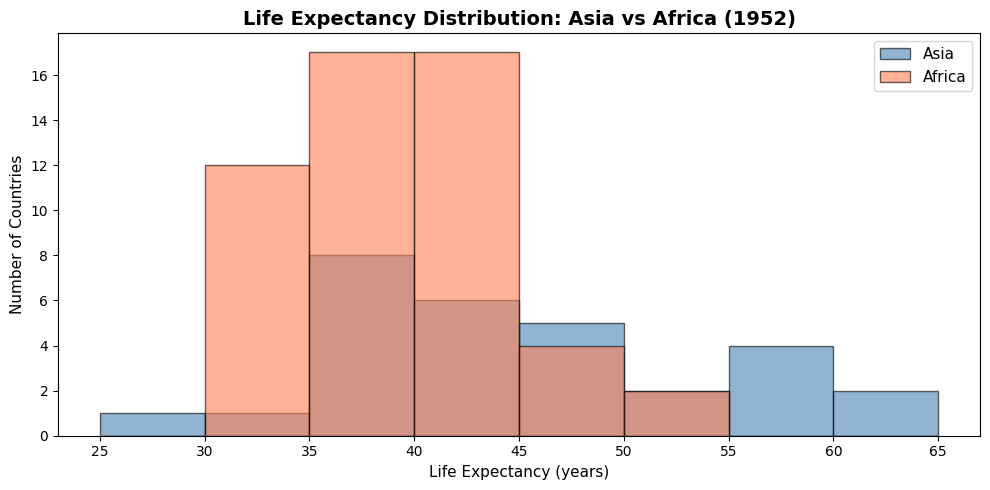

In [5]:
# Create an overlaid histogram to provide another way of comparing
# the two distributions on the same axes

plt.figure(figsize=(10, 5))

# Plot both distributions on the same axes using transparency (alpha)
# so both histograms are visible even where they overlap
plt.hist(asia_1952, bins=bins, color='steelblue', edgecolor='black',
         alpha=0.6, label='Asia')
plt.hist(africa_1952, bins=bins, color='coral', edgecolor='black',
         alpha=0.6, label='Africa')

# Add labels, title, and legend to make the chart readable
plt.title('Life Expectancy Distribution: Asia vs Africa (1952)',
          fontsize=14, fontweight='bold')
plt.xlabel('Life Expectancy (years)', fontsize=11)
plt.ylabel('Number of Countries', fontsize=11)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Key Observations

- **Asia** had a wider spread of life expectancy values in 1952, ranging from under 30 to over 65 years.
- **Africa** had most countries clustered in the 30-45 year range, with a tighter distribution.
- Asia's mean life expectancy was higher than Africa's in 1952, though both continents had countries with very low life expectancy.
- The side-by-side histograms (using `subplot()`) make it easy to compare the shape and spread of each distribution, while the overlaid histogram shows exactly where the two distributions overlap.